# Пайплайны для обучения LLM: pretrain и SFT

В проекте реализуется pretrain и posttrain этапы обучения LLM.

# 1. Этап Pretrain

## 1.1 Данные

In [2]:
import requests
from datasets import load_dataset

files = requests.get("https://api.github.com/repos/JoannaBy/RussianNovels/contents/corpus?ref=master").json()

/opt/miniconda3/envs/nlp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
urls = [
    f["download_url"]
    for f in files
    if f["type"] == "file" and f["name"].endswith(".txt")
]

dataset = load_dataset(
    "text",
    data_files=urls,
    sample_by="document"
)

In [4]:
len(set(urls)) == len(urls)

True

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 108
    })
})

In [6]:
# пример текста из датасета
print(dataset['train'][0]['text'][:1000])


                                 Посвящается Любови Евгеньевне Белозерской



                             Пошел мелкий снег и вдруг  повалил  хлопьями.
                          Ветер завыл; сделалась метель. В одно  мгновение
                          темное  небо  смешалось  с  снежным  морем.  Все
                          исчезло.
                             - Ну, барин, - закричал ямщик, - беда: буран!
                                                       "Капитанская дочка"

                             И судимы были мертвые по написанному в книгах
                          сообразно с делами своими...



ЧАСТЬ ПЕРВАЯ



1


   Велик был год и страшен год по рождестве Христовом 1918, от  начала  же
революции второй. Был он обилен летом солнцем, а зимою снегом, и  особенно
высоко в небе стояли две звезды: звезда пастушеская -  вечерняя  Венера  и
красный, дрожащий Марс.
   Но дни и в мирные и в кровавые годы летят как стрела, и молодые Турбины
не заметили, как в крепком морозе

## 1.2 Препроцессинг данных

### 1.2.1 Базовая очистка

In [7]:
import re
import unicodedata

import re
import unicodedata

import re
import unicodedata

def clean_text(text: str) -> str:
    if not text:
        return ""

    bad_letter_re     = re.compile(r"[^\W\d_А-Яа-яЁё]")   # любая буква НЕ из RU набора
    repeat_punct_re   = re.compile(r"([,;:!?—\-])\1+")    # "!!!"->"!", "--"->"-"
    many_newlines_re  = re.compile(r"\n{3,}")             # 3+ \n -> "\n\n"
    spaces_re         = re.compile(r"[ \t]+")             # пробелы/табы -> один пробел

    t = unicodedata.normalize("NFC", text).replace("\ufeff", "").replace("\xa0", " ")
    t = t.replace("\r\n", "\n").replace("\r", "\n")

    t = many_newlines_re.sub("\n\n", t).strip()           # приводим к абзацам \n\n
    t = re.sub(r"(?<!\n)\n(?!\n)", " ", t)                # одиночные \n внутри абзаца -> пробел (выравниваем "стихи")

    # чистим пробелы уже в "плоском" тексте
    t = "\n\n".join(spaces_re.sub(" ", p).strip() for p in t.split("\n\n"))

    t = re.sub(r"\.{4,}", "...", t)                       # "...." -> "..."
    t = repeat_punct_re.sub(r"\1", t)

    out_pars = []
    for p in (p.strip() for p in t.split("\n\n")):
        if not p:
            continue
        sentences = re.split(r"(?<=[.!?])\s+", p)          # split на предложения по .!? + пробелы
        kept = [s.strip() for s in sentences if s.strip() and not bad_letter_re.search(s)]
        if kept:
            out_pars.append(" ".join(kept))

    return "\n\n".join(out_pars)

In [8]:
clean_dataset = dataset["train"].map(lambda x: {"text": clean_text(x["text"])})

### 1.2.2 Абзацы как чанки

Есть гипотеза, что в качестве чанков для претрейна можно использовать абзацы: они обычно являются смысловыми единицами, и такая сегментация могла бы помочь модели учиться продолжать текст более связно. Если длина абзаца больше длины чанка, то такой абзац можно на минимально необходимое кол-во чанков. 

В данном разделе разобью текст на абзацы и проанализирую их содержимое.

In [9]:
def to_paragraphs(example, idx):
    paragraphs = [p.strip() for p in example["text"].split("\n\n") if p.strip()]
    return {"doc_id": [idx] * len(paragraphs), "text": paragraphs}

paragraphs_ds = clean_dataset.map(
    to_paragraphs,
    with_indices=True,
    batched=False,
    remove_columns=clean_dataset.column_names)

In [10]:
print("*"*10, 'БЫЛО', "*"*10)
print(clean_dataset['text'][0][:500])
print("")
print("*"*10, 'СТАЛО', "*"*10)
print(paragraphs_ds['text'][0][:500])

********** БЫЛО **********
Посвящается Любови Евгеньевне Белозерской

Пошел мелкий снег и вдруг повалил хлопьями. Ветер завыл; сделалась метель. В одно мгновение темное небо смешалось с снежным морем. Все исчезло. - Ну, барин, - закричал ямщик, - беда: буран! "Капитанская дочка"

И судимы были мертвые по написанному в книгах сообразно с делами своими...

ЧАСТЬ ПЕРВАЯ

1

Велик был год и страшен год по рождестве Христовом 1918, от начала же революции второй. Был он обилен летом солнцем, а зимою снегом, и особенно высоко в 

********** СТАЛО **********
['Посвящается Любови Евгеньевне Белозерской', 'Пошел мелкий снег и вдруг повалил хлопьями. Ветер завыл; сделалась метель. В одно мгновение темное небо смешалось с снежным морем. Все исчезло. - Ну, барин, - закричал ямщик, - беда: буран! "Капитанская дочка"', 'И судимы были мертвые по написанному в книгах сообразно с делами своими...', 'ЧАСТЬ ПЕРВАЯ', '1', 'Велик был год и страшен год по рождестве Христовом 1918, от начала же революции втор

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pars_per_doc = paragraphs_ds["text"]
all_pars = [p for doc_pars in pars_per_doc for p in doc_pars] 

Сколько абзацев в документе:


count    108.000000
mean      39.388889
std       77.649203
min        1.000000
5%         1.000000
25%        2.000000
50%       12.000000
75%       44.250000
95%      135.950000
max      654.000000
dtype: float64

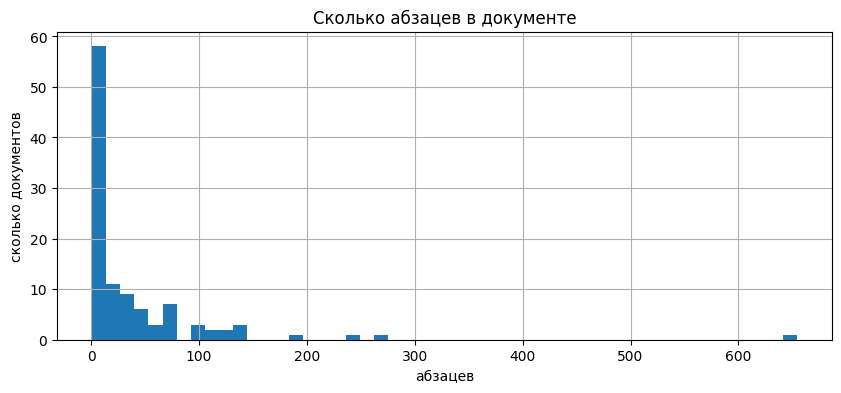

In [12]:
# сколько абзацев в каждом документе
n_pars_per_doc = np.array([len(ps) for ps in pars_per_doc])

print("Сколько абзацев в документе:")
display(pd.Series(n_pars_per_doc).describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

plt.figure(figsize=(10, 4))
plt.hist(n_pars_per_doc, bins=50)
plt.title("Сколько абзацев в документе")
plt.xlabel("абзацев")
plt.ylabel("сколько документов")
plt.grid()
plt.show()

In [13]:
docs_1_2 = [i for i, ps in enumerate(pars_per_doc) if len(ps) in (1, 2)]
print(f"Документов с 1–2 абзацами: {len(docs_1_2)} ({len(docs_1_2)/len(pars_per_doc)*100:.2f}%)")

Документов с 1–2 абзацами: 29 (26.85%)


In [14]:
i = docs_1_2[0]

ps = pars_per_doc[i]

In [15]:
clean_dataset['text'][i]

"Федор Михайлович Достоевский Идиот\n\nФедор Михайлович Достоевский ИДИОТ ЧАСТЬ ПЕРВАЯ. В конце ноября, в оттепель, часов в девять утра, поезд Петербургско#Варшавской железной дороги на всех парах подходил к Петербургу. Было так сыро и туманно, что насилу рассвело; в десяти шагах, вправо и влево от дороги, трудно было разглядеть хоть что#нибудь из окон вагона. Из пассажиров были и возвращавшиеся из#за границы; но более были наполнены отделения для третьего класса, и всё людом мелким и деловым, не из очень далека. Все, как водится, устали, у всех отяжелели за ночь глаза, все назяблись, все лица были бледножелтые, под цвет тумана. В одном из вагонов третьего класса, с рассвета, очутились друг против друга, у самого окна, два пассажира, – оба люди молодые, оба почти налегке, оба не щегольски одетые, оба с довольно замечательными физиономиями, и оба пожелавшие, наконец, войти друг с другом в разговор. Если б они оба знали один про другого, чем они особенно в эту минуту замечательны, то, ко

In [16]:
['глава' in clean_dataset['text'][i].lower()]

[True]

In [17]:
# Длины абзацев

lens = np.array([len(p) for p in all_pars])
pd.DataFrame(lens).describe()

,0
count,4.254000e+03
mean,9.790041e+03
std,3.916580e+04
min,1.000000e+00
25%,1.510000e+02
50%,4.336500e+03
75%,9.254750e+03
max,1.288812e+06


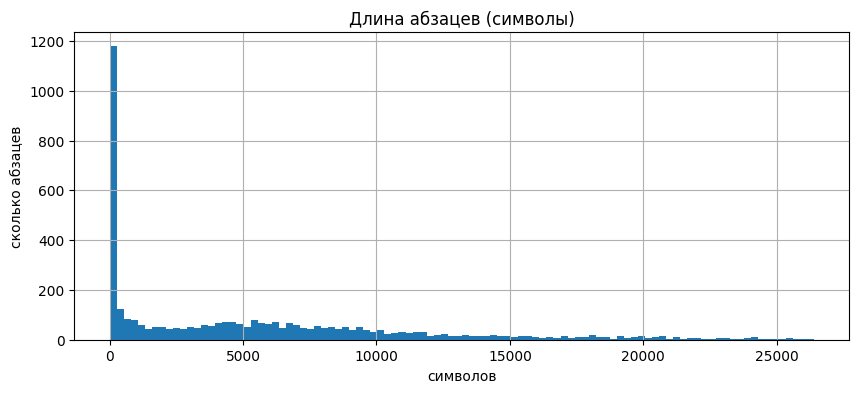

In [18]:
cut = int(np.percentile(lens, 95))

plt.figure(figsize=(10, 4))
counts, edges, _= plt.hist(lens[lens <= cut], bins=100)
plt.title(f"Длина абзацев (символы)")
plt.xlabel("символов")
plt.ylabel("сколько абзацев")
plt.grid()
plt.show()

In [19]:
left, right = edges[0], edges[1]
print(f"Самый левый столбик: [{int(left)}, {int(right)}) символов, абзацев: {int(counts[0])} ({counts[0]/len(lens)})")


Самый левый столбик: [1, 265) символов, абзацев: 1178 (0.2769158439116126)


In [20]:
# Посмотрим примеры коротких абзацев
import random

N = 30
K = 10

short_idx = [i for i, p in enumerate(all_pars) if len(p) < N]
total = len(all_pars)
short_cnt = len(short_idx)
pct = short_cnt / total * 100 if total else 0

print(f"Коротких абзацев (<{N}): {short_cnt} ({pct:.2f}% от всех абзацев)")

random.seed(8)
picked = random.sample(short_idx, k=min(K, len(short_idx)))

for i in picked:
        print(all_pars[i])


Коротких абзацев (<30): 689 (16.20% от всех абзацев)
БАЙ-БАЙ
Только выслужила головушка
НЕЗВАНЫЙ ГОСТЬ
Апреля 25.
ПРИЕХАЛИ В МОНАСТЫРЬ.
2. Продукты производства
Но мне бог возвратит ли все?!
Макаром Девушкиным.
МОРЕ СОЛЕНОЕ И МОРЕ ЗЕЛЕНОЕ
29 апреля


In [21]:
lens_s = pd.Series([len(p) for p in all_pars])
share = (lens_s < 120).mean() * 100
print(f"Доля абзацев короче 120 символов: {share:.2f}%")

Доля абзацев короче 120 символов: 24.07%


In [22]:
# самые частотные
vc = pd.Series(all_pars).value_counts()
display(vc.head(10))

Макар Девушкин.        12
1                       8
* * * * *               6
Часть первая            5
ГЛАВА ПЕРВАЯ            5
В. Д.                   5
6                       4
Макаром Девушкиным.     4
Княжнин.                3
14                      3
Name: count, dtype: int64

Я рассматривала вариант формировать обучающие примеры, разделяя текст на абзацы и используя подход "чанк = абзац". После очистки данных (нормализация пробелов и пунктуации, а также удаление предложений с буквами вне современного русского алфавита) разбила корпус на абзацы и проанализировала. 
Выяснилось, что: 
- В 26.85% документов у нас 1-2 формальных абзаца, т.е. часть текста не отформатирована нормально.
- Заметная доля абзацев очень короткие: около 25% имеют длину меньше 120 символов. Если использовать абзацы как чанки, то значительная часть обучающих примеров окажется слишком короткой, а обучение станет менее эффективным (много паддинга и меньше полезных токенов на шаг).

Дополнительно, при ручном просмотре самых коротких абзацев видно, что среди них много служебного "мусора": заголовки глав ("ГЛАВА 1", "ЧАСТЬ ПЕРВАЯ"), одиночные номера, декоративные разделители ("* * * * *"). Такие строки часто повторяются и могут смещать модель в сторону генерации служебных конструкций.

В итоге принято решение отойти от стратегии “чанк = абзац” и перейти к формированию чанков по токенам с фиксированной длиной контекста 512.
При этом на текстовом уровне добавим фильтрацию наиболее типичных служебных вставок (названия глав, их нумерация и т.п.).


### 1.2.3 Доочистка служебных частей

In [23]:
def is_service_paragraph(p, max_heading_len=80):
    s = p.strip()

    # для проверки убираем "обвязку" из не-букв/не-цифр по краям
    s_check = re.sub(r"^[^\wА-Яа-яЁё]+|[^\wА-Яа-яЁё]+$", "", s).strip()

    # только римская цифра (IV, IV., IV))
    if re.fullmatch(r"[IVXLCDM]{1,12}\s*[.)]?\s*", s_check, flags=re.IGNORECASE):
        return True

    # только цифры/символы/пробелы
    if re.fullmatch(r"[\d\W_]+", s_check):
        return True

    # короткий заголовок главы/части/раздела )
    if len(s_check) <= max_heading_len and re.match(r"^(глава|часть|раздел|предисловие|послесловие)\b", s_check, flags=re.IGNORECASE):
        return True

    # нумерованный короткий заголовок: "1. ...", "4) ...", "12. ..."
    if len(s_check) <= max_heading_len and re.match(r"^\d{1,3}\s*[.)]\s+\S+", s_check):
        return True

    return False

In [24]:
to_remove = list(set(p for p in all_pars if is_service_paragraph(p)))

to_remove[:10]

['25',
 '1',
 'Глава 1. НАЧАЛО ПРИКЛЮЧЕНИЙ',
 '2',
 '3',
 'Глава 7. Рокк',
 'Глава 16. УДАЧНАЯ ЖЕНИТЬБА',
 'Глава 2. Цветной завиток',
 'ЧАСТЬ ТРЕТЬЯ.',
 '6']

Есть гипотеза, что первые короткие абзацы в текстах также носят служебный характер. Посмотрим на них.

In [25]:
N = 120 

first_pars = [ps[0].strip() for ps in paragraphs_ds["text"] if ps and ps[0].strip()]
first_short = [p for p in first_pars if len(p) < N]

print(f"Коротких первых абзацев (<{N}): {len(first_short)} ({len(first_short)/len(first_pars)*100:.2f}%)")

for p in first_short:
    print("\n", "*"*10)
    print(p)


Коротких первых абзацев (<120): 55 (50.93%)

 **********
Посвящается Любови Евгеньевне Белозерской

 **********
Повесть о том, как близнецы погубили делопроизводителя

 **********
Мастер И Маргарита

 **********
Глава 1. Куррикулюм витэ профессора Персикова

 **********
Михаил Булгаков. Театральный роман * (Записки покойника) *

 **********
Полотенце с петухом

 **********
Антон Павлович Чехов Дама с собачкой Рассказы – 0 Антон Павлович Чехов

 **********
Антон Павлович Чехов Дядя Ваня

 **********
Федор Михайлович Достоевский Бесы

 **********
Федор Михайлович Достоевский Идиот

 **********
РОМАН

 **********
ЧАСТЬ ВТОРАЯ.

 **********
ЧАСТЬ ТРЕТЬЯ.

 **********
ЧАСТЬ ЧЕТВЕРТАЯ.

 **********
Часть первая

 **********
Роман в четырех частях

 **********
Глава первая

 **********
Глава первая

 **********
Часть первая

 **********
ГЛАВА 1

 **********
От станции Себряково до Г-ской станицы.

 **********
Очерк

 **********
отвечала Владимир Набоков Ада, или Радости страсти Семейная хрони

In [26]:
def drop_service_patterns(text: str, to_remove: list[str], first_short=None) -> str:
    if not text:
        return ""

    # сначала вырезаем короткий первый абзац, если текст начинается с него
    for p in first_short:
        s = (p or "").strip()
        if text.lstrip().startswith(s):
            text = text.lstrip()[len(s):]
            text = re.sub(r"^\s*\n{1,}\s*", "", text)  
            break  # одного первого абзаца достаточно
    
    # затем вырезаем все служебные абзацы, которые могут встречаться в любом месте текста
    for p in to_remove:
        s = (p or "").strip()
        if not s:
            continue

        if re.fullmatch(r"\d{1,4}", s):
            text = text.replace(f"\n\n{s}\n\n", "\n\n")
        else:
            text = text.replace(s, "")

    # прибраться
    text = re.sub(r"[ \t]{2,}", " ", text)
    text = re.sub(r"\s+([,.;:!?])", r"\1", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r" *\n *", "\n", text).strip()

    return text

In [27]:
clean_dataset = clean_dataset.map(
    lambda x: {"text": drop_service_patterns(x["text"], to_remove, first_short=first_short)}
)

Map: 100%|██████████| 108/108 [00:03<00:00, 30.53 examples/s]


In [28]:
for i, t in enumerate(dataset["train"]["text"][:5], 1):
    print(f"{i}) {t[:100]}")

1) 
                                 Посвящается Любови Евгеньевне Белозерской



                     
2)              Повесть о том, как близнецы погубили делопроизводителя




1. Происшествие 20-го числа

3) Мастер И Маргарита

Михаил Афанасиевич Булгаков
ЧАСТЬ ПЕРВАЯ
 
...Так кто ж ты, наконец?
– Я – часть
4) Глава 1. Куррикулюм витэ профессора Персикова


     16  апреля  1928 года,  вечером, профессор зоол
5) Михаил Булгаков. Театральный роман
* (Записки покойника) * 



ПРЕДИСЛОВИЕ



       Предупреждаю чи


In [29]:
for i, t in enumerate(clean_dataset["text"][:5], 1):
    print(f"{i}) {t[:100]}")

1) Пошел мелкий снег и вдруг повалил хлопьями. Ветер завыл; сделалась метель. В одно мгновение темное н
2) Происшествие 20-го числа

В то время, как все люди скакали с одной службы на другую, товарищ Коротко
3) Михаил Афанасиевич Булгаков...Так кто ж ты, наконец? – Я – часть той силы, что вечно хочет зла и веч
4) Профессор зажег верхний матовый шар и огляделся. Начало ужасающей катастрофы нужно считать заложенны
5) Предупреждаю читателя, что к сочинению этих записок я не имею никакого отношения и достались они мне


## 1.3 Собственный токенизатор

In [30]:
from tokenizers import (
    decoders,
    models,
    normalizers,
    pre_tokenizers,
    processors,
    trainers,
    Tokenizer,
)
from transformers import PreTrainedTokenizerFast


VOCAB_SIZE = 3000
SPECIAL_TOKENS = ["<pad>", "<bos>", "<eos>", "<unk>"]

tokenizer = Tokenizer(models.BPE(unk_token="<unk>"))
tokenizer.normalizer = normalizers.NFC()

tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)

trainer = trainers.BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=SPECIAL_TOKENS,
    show_progress=True
)

In [31]:
def get_training_corpus():
    for i in range(0, len(clean_dataset), 1000):
        yield clean_dataset[i : i + 1000]["text"]

In [32]:
tokenizer.train_from_iterator(get_training_corpus(), trainer=trainer)

In [33]:
tokenizer.post_processor = processors.ByteLevel(trim_offsets=False)
tokenizer.decoder = decoders.ByteLevel()

In [34]:
wrapped_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    bos_token="<bos>",
    eos_token="<eos>",
    unk_token="<unk>",
    pad_token="<pad>",
)

In [35]:
print("Vocab size:", wrapped_tokenizer.vocab_size)
print("Special tokens:", wrapped_tokenizer.special_tokens_map)

Vocab size: 3000
Special tokens: {'bos_token': '<bos>', 'eos_token': '<eos>', 'unk_token': '<unk>', 'pad_token': '<pad>'}


In [36]:
s = "Привет, мир!"
enc = wrapped_tokenizer(s, add_special_tokens=False)
print(wrapped_tokenizer.convert_ids_to_tokens(enc["input_ids"])[:30])

['ÐŁ', 'ÑĢ', 'Ð¸Ð²', 'ÐµÑĤ', ',', 'ĠÐ¼Ð¸ÑĢ', '!']


In [37]:
wrapped_tokenizer.save_pretrained("tokenizer")

('tokenizer/tokenizer_config.json', 'tokenizer/tokenizer.json')

## 1.4 Токенизация данных 

In [38]:
def tokenize(batch):
    return wrapped_tokenizer(batch["text"], add_special_tokens=False)

tokenized = clean_dataset.map(
    tokenize,
    batched=True,
    remove_columns=clean_dataset.column_names,
)

Map: 100%|██████████| 108/108 [00:09<00:00, 11.87 examples/s]


In [39]:
def train_data_to_chunk(batch, group_size=512):
    bos_id = wrapped_tokenizer.bos_token_id
    eos_id = wrapped_tokenizer.eos_token_id

    input_ids = []
    labels = []

    inner = group_size - 2  

    for ids in batch["input_ids"]:        
        for i in range(0, len(ids), inner):
            chunk = ids[i:i+inner]
            if len(chunk) < inner:
                continue  # хвост выкидываем

            seq = [bos_id] + chunk + [eos_id]
            input_ids.append(seq)
            labels.append(seq.copy())

    return {"input_ids": input_ids, "labels": labels}

In [40]:
chunk_dataset = tokenized.map(
    lambda batch: train_data_to_chunk(batch, group_size=512),
    batched=True,
    remove_columns=tokenized.column_names,  
)

Map: 100%|██████████| 108/108 [00:03<00:00, 31.12 examples/s]


In [41]:
ids = chunk_dataset[8]["input_ids"]
decoded = wrapped_tokenizer.decode(ids)

print(decoded[:500])

<bos>но-испуганны. Что же значит, что Тальберга до сих пор нет? Старший чувствует ее волнение и поэтому не говорит ни слова, хоть сказать ему и очень хочется. В Святошине. Сомнений в этом никаких быть не может. Стреляют в двенадцати верстах от города, не дальше. Что за штука? Николка взялся за шпингалет, другой рукой прижал стекло, будто хочет выдавить его и вылезть, и нос расплющил. - Хочется мне туда поехать. Узнать, в чем дело... - Ну да, тебя там не хватало... Елена говорит в тревоге. Вот не


## 1.5 Инициализация ЛЛМ

In [42]:
from transformers import LlamaConfig, LlamaForCausalLM

config = LlamaConfig(
    vocab_size=wrapped_tokenizer.vocab_size,
    bos_token_id=wrapped_tokenizer.bos_token_id,
    eos_token_id=wrapped_tokenizer.eos_token_id,
    pad_token_id=wrapped_tokenizer.pad_token_id,

    hidden_size=1024,
    intermediate_size=1536,
    num_hidden_layers=16,
    num_attention_heads=16,
    num_key_value_heads=8,

    max_position_embeddings=512,
    rms_norm_eps=1e-6,
    rope_theta=10000.0,
)

model = LlamaForCausalLM(config)
model.config.use_cache = False

/opt/miniconda3/envs/nlp/lib/python3.10/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/miniconda3/envs/nlp/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <0B7EB158-53DC-3403-8A49-22178CAB4612> /opt/miniconda3/envs/nlp/lib/python3.10/site-packages/torchvision/image.so
  Reason: tried: '/opt/miniconda3/envs/nlp/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/miniconda3/envs/nlp/lib/python3.10/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/miniconda3/envs/nlp/lib/python3.10/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/miniconda3/envs/nlp/bin/../lib/libjpeg.9.dylib' (no such file)'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` in

In [43]:
n_params = sum(p.numel() for p in model.parameters())
print(f"Params: {n_params/1e6:.1f}M")

Params: 132.0M


## 1.6 Реализация Trainer с коллбэками для валидации качества на промптах

In [44]:
import torch
from transformers import TrainingArguments, Trainer, TrainerCallback

test_prompts = [
    "Все мысли, которые имеют огромные последствия",
    "Сила войска зависит от его духа",
    "Мысль о том, что он принес страдания",
    "Человек сознает себя свободным",
    "Что бы ни случилось, я всегда буду",
    "Любовь мешает смерти",
    "Нет, жизнь не кончена",
    "Всякая мысль, даже самая простая",
    "Война не любезность, а самое гадкое дело",
    "Чтобы жить честно"
]

In [45]:
def data_collator(features):
    input_ids = torch.tensor([f["input_ids"] for f in features], dtype=torch.long)
    labels = torch.tensor([f["labels"] for f in features], dtype=torch.long)
    attention_mask = torch.ones_like(input_ids, dtype=torch.long)
    return {
        "input_ids": input_ids,
        "labels": labels,
        "attention_mask": attention_mask,
    }

In [ ]:
class PromptEvalCallback(TrainerCallback):
    def __init__(self, tokenizer, prompts, max_new_tokens=120, every_steps=1000):
        self.tokenizer = tokenizer
        self.prompts = prompts
        self.max_new_tokens = max_new_tokens
        self.every_steps = every_steps

    @torch.no_grad()
    def _generate(self, model, tag: str):
        model.eval()
        dev = next(model.parameters()).device

        print("\n" + "=" * 30)
        print(f"PROMPT EVAL @ {tag}")
        print("=" * 30)

        for p in self.prompts:
            enc = self.tokenizer(p, return_tensors="pt", add_special_tokens=False)
            enc = {k: v.to(dev) for k, v in enc.items()}

            out = model.generate(
                **enc,
                max_new_tokens=self.max_new_tokens,
                do_sample=True,
                temperature=0.9,
                top_p=0.95,
                repetition_penalty=1.05,
                no_repeat_ngram_size=3,  
                eos_token_id=self.tokenizer.eos_token_id,
                pad_token_id=self.tokenizer.pad_token_id,
            )

            txt = self.tokenizer.decode(out[0], skip_special_tokens=True)
            print("\n---")
            print(txt)

        model.train()

    def on_step_end(self, args, state, control, **kwargs):
        if self.every_steps and state.global_step > 0 and state.global_step % self.every_steps == 0:
            self._generate(kwargs["model"], tag=f"step_{state.global_step}")

    def on_epoch_end(self, args, state, control, **kwargs):
        self._generate(kwargs["model"], tag=f"epoch_{state.epoch}")

In [ ]:
assert torch.cuda.is_available(), "CUDA не доступна. Проверь драйвер/torch build."
device = torch.device("cuda")

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("gpu:", torch.cuda.get_device_name(0))

model.to(device)
model.config.use_cache = False

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(3000, 1024, padding_idx=0)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (k_proj): Linear(in_features=1024, out_features=512, bias=False)
          (v_proj): Linear(in_features=1024, out_features=512, bias=False)
          (o_proj): Linear(in_features=1024, out_features=1024, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=1024, out_features=1536, bias=False)
          (up_proj): Linear(in_features=1024, out_features=1536, bias=False)
          (down_proj): Linear(in_features=1536, out_features=1024, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((1024,), eps=1e-06)
        (post_attention_layernorm): LlamaRMSNorm((1024,), eps=1e-06)
      )
    )
    (norm): LlamaRMSNorm((1024,), eps=1

In [ ]:
output_dir = "pretrain_vm"

vm_args = TrainingArguments(
    output_dir=output_dir,

    per_device_train_batch_size=4,
    gradient_accumulation_steps=16,  
    max_steps=200,  #ПОТОМ ЗАМЕНИМ                  
    warmup_steps=200,
    learning_rate=2e-4,
    weight_decay=0.1,                
    fp16=True,
    bf16=False,
    logging_steps=50,
    save_steps=500,
    save_total_limit=2,
    report_to="none",
    remove_unused_columns=False,
    max_grad_norm=1.0,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    load_best_model_at_end=False,
)

In [ ]:
trainer = Trainer(
    model=model,
    args=vm_args,
    train_dataset=chunk_dataset,
    data_collator=data_collator,
    callbacks=[PromptEvalCallback(wrapped_tokenizer, test_prompts, max_new_tokens=120, every_steps=1000)],
)

trainer.train()


Step,Training Loss
20,6.528302
40,6.402602
60,6.209027
80,6.005138
100,5.903734
120,5.798449
140,5.726470
160,5.621348
180,5.539000
200,5.461469



PROMPT EVAL @ step_200

---
Все мысли, которые имеют огромные последствия, что я не было, что я не знаю, что я#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#нибудь#

---
Сила войска зависит от его духа ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( ( (

---
Мысль о том, что он принес страдания, и не было, что я не было, что я#то#то#то#то#то#то#то#то#то#то#то#то#то#то#то#то#то#то#то#то#то#то#то#то


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.79it/s]


TrainOutput(global_step=200, training_loss=5.91955379486084, metrics={'train_runtime': 216.2913, 'train_samples_per_second': 7.397, 'train_steps_per_second': 0.925, 'total_flos': 633740879462400.0, 'train_loss': 5.91955379486084, 'epoch': 0.8})

In [ ]:
@torch.no_grad()
def generate_on_prompts(model, tokenizer, prompts, max_new_tokens=120):
    model.eval()
    dev = next(model.parameters()).device

    for p in prompts:
        enc = tokenizer(p, return_tensors="pt", add_special_tokens=False)
        enc = {k: v.to(dev) for k, v in enc.items()}

        out = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.9,
            top_p=0.95,
            repetition_penalty=1.05,
            no_repeat_ngram_size=3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )

        print("\n===")
        print("PROMPT:", p)
        print(tokenizer.decode(out[0], skip_special_tokens=True))

generate_on_prompts(model, wrapped_tokenizer, test_prompts, max_new_tokens=120)



===
PROMPT: Все мысли, которые имеют огромные последствия
Все мысли, которые имеют огромные последствия, кромеездидилась на его в пить оскали в котором на крывалось и с вами в одномхе. Панными полнке от меня кутный лине от вас по ними его в том, но я уны ее рахафотном время на фамедом ее в руках на колкакного лраен. Опорлнул он измитыми. – Вбесли его в текурел на полху.)-то не надо соли в немуфадовича.

===
PROMPT: Сила войска зависит от его духа
Сила войска зависит от его духаетыекетьков).лена Надотркомную. Ну Срь. Тылена (ервевич ( ()… Боня). Раз… Так… (�аврок (д)… Ановевна… ( (ех… (еритесь). (ите… ( Андре… Я ялена… ()ниц. Ч А… Аначаницлена… П). (айте ()). Не выитьниц (… ( ведьницовевна…… Подоня). ( ( Ае (. А… (стр… (итесь. С (нов (… Не. (

===
PROMPT: Мысль о том, что он принес страдания
Мысль о том, что он принес страдания у него палемовый с аресомине краеа. Но я, и на нее, что все, чтобы в ролок он. Вот вдруг, что жессор. - Я же вы-то не знаю! Он, - он это, вы не все уже врачу. -

# 2. Этап Post-train SFT

Обучим базовую модель Qwen2.5-0.5B генерировать ответы на инструктивные русскоязычные вопросы.

## 2.1 Подготовка датасета для дообучения

In [57]:
from datasets import load_dataset

ds = load_dataset("d0rj/alpaca-cleaned-ru")

Generating train split: 100%|██████████| 51760/51760 [00:00<00:00, 712504.18 examples/s]


In [89]:
ds['train'][6]

{'input': '4/16',
 'instruction': 'Объясните, почему следующая дробь равна 1/4',
 'output': 'Дробь 4/16 эквивалентна 1/4, потому что обе дроби представляют одно и то же значение. Дробь можно упростить, разделив числитель и знаменатель на общий множитель. В этом случае 4 является общим делителем как числителя, так и знаменателя числа 4/16. Когда мы делим оба числа на 4, мы получаем 4/4 = 1 и 16/4 = 4, поэтому упрощенная дробь равна 1/4. В качестве альтернативы, мы можем думать об этом с точки зрения умножения. Например, если мы умножим числитель и знаменатель дроби 1/4 на 4, мы получим (1x4)/(4x4), или 4/16. Поскольку обе дроби могут быть получены из другой путем умножения или деления на одно и то же число, они представляют собой одно и то же значение и эквивалентны.'}

In [79]:
print('Заполненность полей: ')

for k in ds['train'].column_names:
    print(k, f"{sum(s!='' for s in ds['train'][k]) * 100/len(ds['train']):.2f}%")

Заполненность полей: 
input 37.01%
instruction 100.00%
output 100.00%


In [90]:
def preprocess_data(example):
    content = example["instruction"]
    if example["input"]!='':
        content = content  + "\n\n" + example["input"]

    return {
        "prompt": [
            {"role": "user", "content": content},
            ],
        "completion": [
            {"role": "assistant", "content": example["output"]}
        ],
    }

In [91]:
preprocess_ds = ds["train"].map(preprocess_data, remove_columns=ds["train"].column_names)

Map: 100%|██████████| 51760/51760 [00:01<00:00, 35479.73 examples/s]


In [ ]:
from unsloth import FastLanguageModel
import torch

{'prompt': [{'content': 'Дайте три совета, как оставаться здоровым.',
   'role': 'user'}],
 'completion': [{'content': '1. Соблюдайте сбалансированную и питательную диету. Убедитесь, что в ваш рацион входят разнообразные фрукты и овощи, нежирный белок, цельнозерновые продукты и полезные жиры. Это помогает обеспечить ваш организм необходимыми питательными веществами для оптимального функционирования и может помочь предотвратить хронические заболевания.\n\n2. Занимайтесь регулярной физической активностью. Упражнения имеют решающее значение для поддержания крепких костей, мышц и здоровья сердечно-сосудистой системы. Старайтесь уделять не менее 150 минут умеренным аэробным упражнениям или 75 минут интенсивным упражнениям каждую неделю.\n\n3. Высыпайтесь. Достаточное количество качественного сна имеет решающее значение для физического и психического благополучия. Он помогает регулировать настроение, улучшать когнитивные функции и поддерживает здоровый рост и иммунную функцию. Старайтесь спа